In [78]:
# ROME Structural Analysis - Comprehensive Comparison
# Load data and select case for analysis

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# === CONFIGURATION ===
JSON_FILE = "./analysis_out/rome_structural_gpt2-medium_2026-01-25_23-03-33.json"

# Load data
with open(JSON_FILE) as f:
    data = json.load(f)

# Show available cases
print("=== Available Test Cases ===")
print(f"Model: {data['metadata']['model']}")
print(f"Target Layer: {data['metadata']['target_layer']}")
print(f"Number of tests: {data['metadata']['n_tests']}")
print("\nCases:")
for i, test in enumerate(data['tests']):
    status = "✓" if test.get('error') is None else f"✗ ({test['error'][:30]}...)"
    rome_ok = test.get('rome', {}).get('success', False)
    print(f"  [{i}] Case {test['case_id']}: {test['subject']} | ROME: {'✓' if rome_ok else '✗'} | {status}")

# === SELECT CASE ID HERE ===
SELECTED_CASE_ID = 1  # <-- CHANGE THIS TO ANALYZE DIFFERENT CASES

=== Available Test Cases ===
Model: gpt2-medium
Target Layer: 8
Number of tests: 5

Cases:
  [0] Case 0: Danielle Darrieux | ROME: ✓ | ✓
  [1] Case 1: Edwin of Northumbria | ROME: ✓ | ✓
  [2] Case 2: Toko Yasuda | ROME: ✓ | ✓
  [3] Case 3: Autonomous University of Madrid | ROME: ✓ | ✓
  [4] Case 4: Lyon | ROME: ✗ | ✓


In [ ]:
case = next((t for t in data['tests'] if t['case_id'] == SELECTED_CASE_ID), None)
if case is None:
    raise ValueError(f"Case {SELECTED_CASE_ID} not found!")

target_layer = data['metadata']['target_layer']
print(f"=== Analyzing Case {SELECTED_CASE_ID}: {case['subject']} ===")
print(f"Target (edited) layer: {target_layer}")

if case.get('error'):
    print(f"⚠️  Case has error: {case['error']}")
else:
    rome = case['rome']
    print(f"\nROME Edit Results:")
    print(f"  Success: {rome['success']}")
    print(f"  Predicted: {rome['predicted']}")
    print(f"  k_norm: {rome['k_norm']:.4f}")
    print(f"  v_norm: {rome['v_norm']:.4f}")
    print(f"  delta_norm: {rome['delta_norm']:.4f}")

=== Analyzing Case 1: Edwin of Northumbria ===
Target (edited) layer: 8

ROME Edit Results:
  Success: True
  Predicted:  Islam
  k_norm: 5.7070
  v_norm: 119.5853
  delta_norm: 115.8750


## 1. Normal Detection - Affected Layer vs Other Layers

This uses the original weights as reference to detect changes.

=== NORMAL DETECTION (with original weights reference) ===

Detected anomalous layer: 8 ✓ CORRECT
Layer Z-score: 4.7958
Is likely ROME: True
P-value: 0.000000
Rank-one score: 1.000000
Effective rank of delta: 1.2285


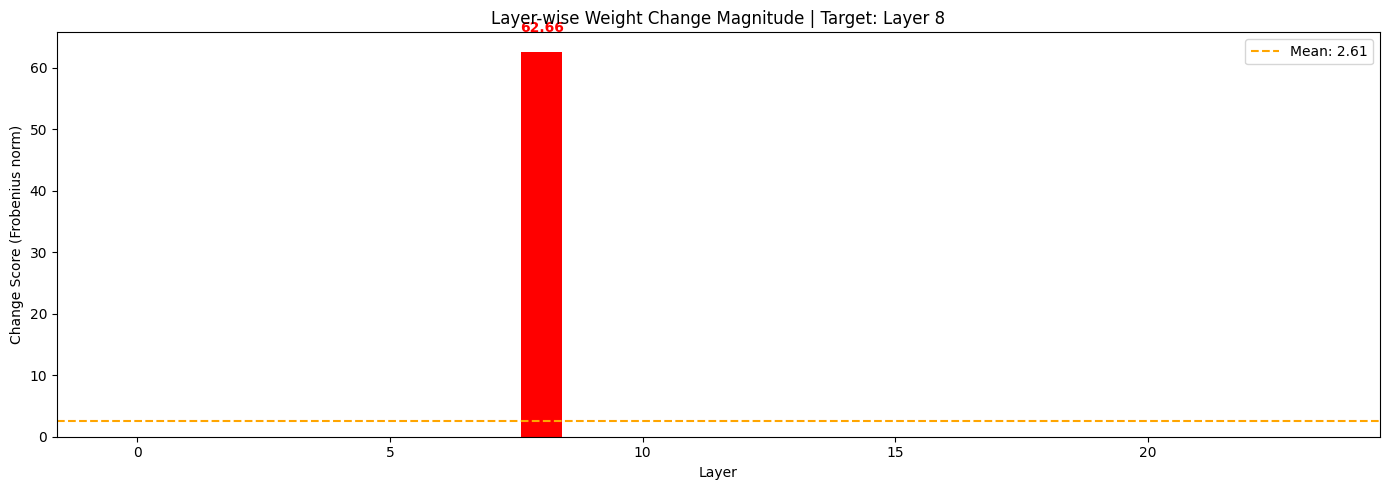


--- Layer Score Statistics ---
Target layer (8) score: 62.6562
Other layers mean: 0.0000
Other layers std: 0.0000
Target vs others ratio: 626562500000.00x


In [80]:
normal = case.get('normal_detection', {})

if normal:
    print("=== NORMAL DETECTION (with original weights reference) ===\n")
    
    # Detection result
    detected_layer = normal.get('anomalous_layer')
    is_correct = detected_layer == target_layer
    print(f"Detected anomalous layer: {detected_layer} {'✓ CORRECT' if is_correct else '✗ WRONG'}")
    print(f"Layer Z-score: {normal.get('layer_z_score', 0):.4f}")
    print(f"Is likely ROME: {normal.get('is_likely_rome', False)}")
    print(f"P-value: {normal.get('p_value', 1):.6f}")
    print(f"Rank-one score: {normal.get('rank_one_score', 0):.6f}")
    print(f"Effective rank of delta: {normal.get('effective_rank', 0):.4f}")
    
    # All layer scores comparison
    all_scores = normal.get('all_layer_scores', {})
    layers = sorted([int(k) for k in all_scores.keys()])
    scores = [all_scores[str(l)] for l in layers]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    bars = ax.bar(layers, scores, color=colors)
    ax.axhline(y=np.mean(scores), color='orange', linestyle='--', label=f'Mean: {np.mean(scores):.2f}')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Change Score (Frobenius norm)')
    ax.set_title(f'Layer-wise Weight Change Magnitude | Target: Layer {target_layer}')
    ax.legend()
    
    # Annotate target layer
    if str(target_layer) in all_scores:
        target_score = all_scores[str(target_layer)]
        ax.annotate(f'{target_score:.2f}', xy=(target_layer, target_score), 
                    xytext=(target_layer, target_score + max(scores)*0.05),
                    ha='center', fontweight='bold', color='red')
    plt.tight_layout()
    plt.show()
    
    # Statistics
    other_scores = [s for l, s in zip(layers, scores) if l != target_layer]
    target_score = all_scores.get(str(target_layer), 0)
    print(f"\n--- Layer Score Statistics ---")
    print(f"Target layer ({target_layer}) score: {target_score:.4f}")
    print(f"Other layers mean: {np.mean(other_scores):.4f}")
    print(f"Other layers std: {np.std(other_scores):.4f}")
    print(f"Target vs others ratio: {target_score / (np.mean(other_scores) + 1e-10):.2f}x")
else:
    print("No normal detection data available")

=== NEURON GROUP ANALYSIS ===

Most affected group: magnitude/magnitude_q4
Group MSD: 0.223145


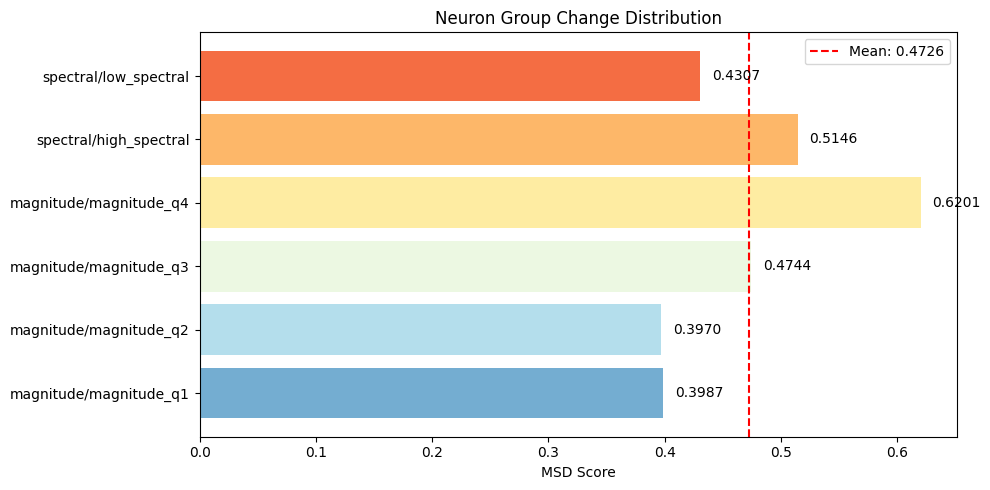


--- Top Singular Values of Delta ---
  σ_1: 62.658253
  σ_2: 0.001297
  σ_3: 0.001629
  σ_4: 0.001376
  σ_5: 0.001366
  Ratio σ₁/σ₂: 48312.38


In [81]:
# Group-level analysis (which neuron groups changed most)
if normal and 'group_scores' in normal:
    print("=== NEURON GROUP ANALYSIS ===\n")
    print(f"Most affected group: {normal.get('most_affected_group')}")
    print(f"Group MSD: {normal.get('group_msd', 0):.6f}")
    
    group_scores = normal['group_scores']
    groups = list(group_scores.keys())
    values = list(group_scores.values())
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(groups)))
    bars = ax.barh(groups, values, color=colors)
    ax.set_xlabel('MSD Score')
    ax.set_title('Neuron Group Change Distribution')
    ax.axvline(x=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.4f}')
    ax.legend()
    
    # Add values on bars
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Top singular values of delta
    if 'top_singular_values' in normal:
        svs = normal['top_singular_values']
        print(f"\n--- Top Singular Values of Delta ---")
        for i, sv in enumerate(svs):
            print(f"  σ_{i+1}: {sv:.6f}")
        print(f"  Ratio σ₁/σ₂: {svs[0]/(svs[1]+1e-10):.2f}")

## 2. Blind Detection - Layer Features Comparison

This analyzes only the modified weights (no original reference). Compares the target layer features vs all other layers.

In [82]:
blind = case.get('blind_detection', {})

if blind and 'layer_features' in blind:
    print("=== BLIND DETECTION (no original reference) ===\n")
    
    detected_layer = blind.get('anomalous_layer')
    is_correct = detected_layer == target_layer
    print(f"Detected anomalous layer: {detected_layer} {'✓ CORRECT' if is_correct else '✗ WRONG'}")
    print(f"Layer anomaly score: {blind.get('layer_anomaly_score', 0):.4f}")
    
    # Build DataFrame from layer features
    layer_features = blind['layer_features']
    df_layers = pd.DataFrame.from_dict(layer_features, orient='index')
    df_layers.index = df_layers.index.astype(int)
    df_layers = df_layers.sort_index()
    
    # Replace infinity with NaN for calculations
    df_layers = df_layers.replace([np.inf, -np.inf], np.nan)
    
    print(f"\n--- Layer Features Overview ---")
    display(df_layers)
else:
    print("No blind detection data available")

=== BLIND DETECTION (no original reference) ===

Detected anomalous layer: 8 ✓ CORRECT
Layer anomaly score: 2.2160

--- Layer Features Overview ---


,effective_rank,spectral_gap,top1_energy,pcs,norm_cv
0,928.115845,1.624623,0.028871,0.0,0.147217
1,951.004395,1.606684,0.063378,0.0,0.245605
2,950.639404,1.617451,0.049927,0.0,0.209229
3,938.978333,2.965128,0.079913,0.0,0.246704
4,937.210083,3.352881,0.077819,0.0,0.228149
5,936.862000,2.693954,0.065274,NaN,0.199341
6,939.254150,2.037915,0.040075,0.0,0.174072
7,940.932007,1.698870,0.030117,0.0,0.189453
8,932.815796,2.307817,0.118766,0.0,0.291260
9,944.149536,1.110997,0.012843,0.0,0.176147


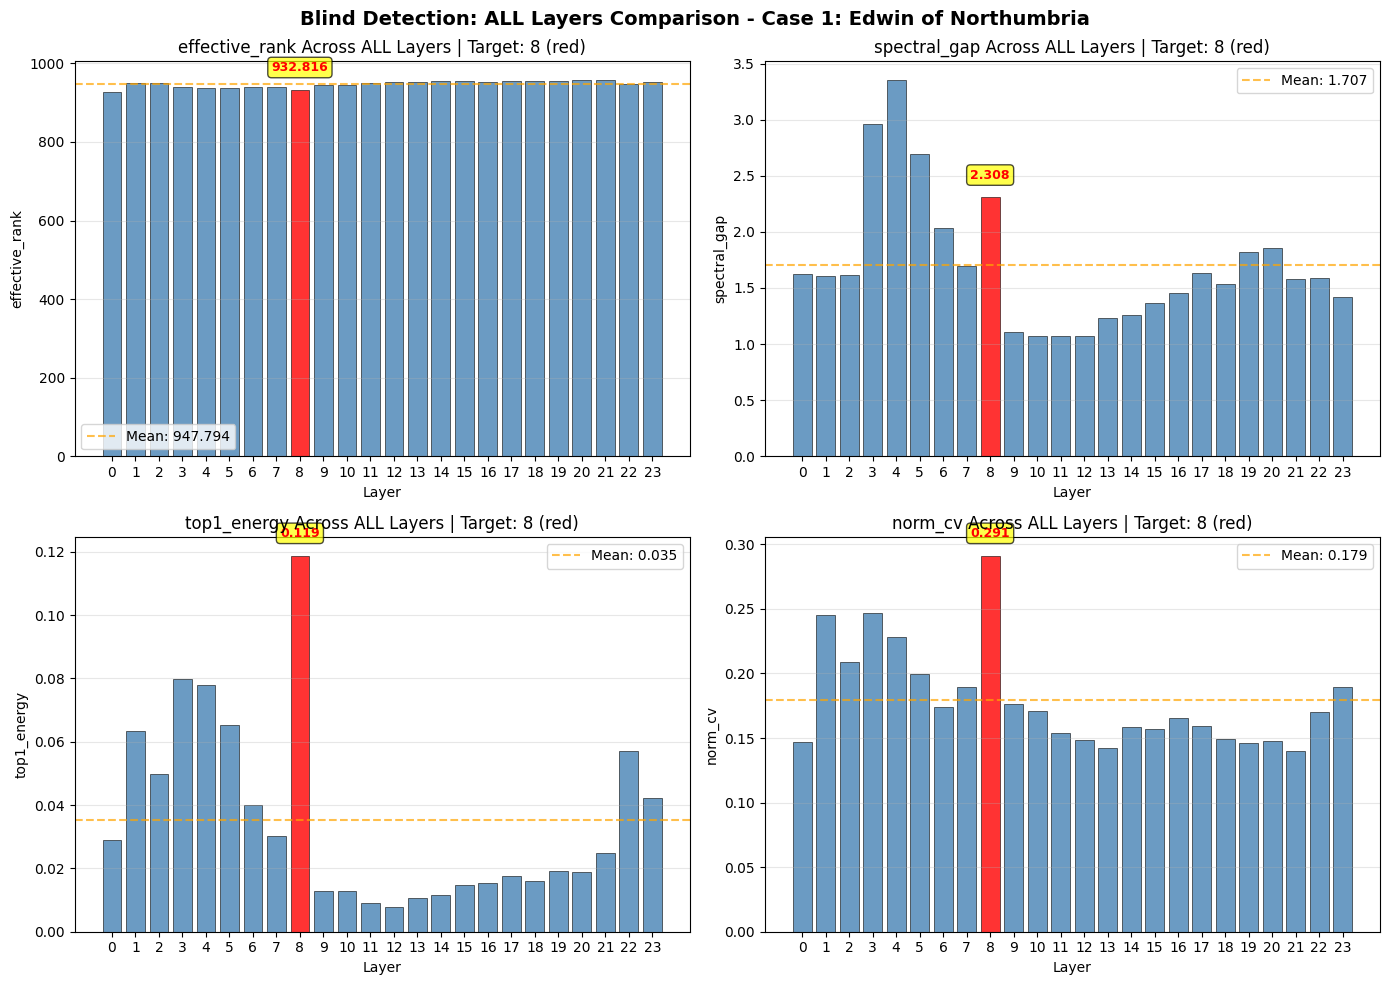

In [83]:
# Visualize each metric: Target Layer vs ALL Other Layers
if blind and 'layer_features' in blind:
    metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for ax, metric in zip(axes, metrics):
        # Get ALL layer values for this metric (no dropna on index)
        all_layers = list(range(len(df_layers)))
        vals = [df_layers.loc[l, metric] if l in df_layers.index else np.nan for l in all_layers]
        
        colors = ['red' if l == target_layer else 'steelblue' for l in all_layers]
        bars = ax.bar(all_layers, vals, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Add mean line (excluding NaN)
        valid_vals = [v for v in vals if not np.isnan(v)]
        if valid_vals:
            ax.axhline(y=np.mean(valid_vals), color='orange', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(valid_vals):.3f}')
        
        ax.set_xlabel('Layer')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} Across ALL Layers | Target: {target_layer} (red)')
        ax.set_xticks(all_layers)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # Annotate target layer value
        if target_layer < len(vals) and not np.isnan(vals[target_layer]):
            max_val = np.nanmax(vals)
            ax.annotate(f'{vals[target_layer]:.3f}', xy=(target_layer, vals[target_layer]), 
                       xytext=(target_layer, vals[target_layer] + max_val*0.05),
                       ha='center', fontweight='bold', color='red', fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.suptitle(f'Blind Detection: ALL Layers Comparison - Case {SELECTED_CASE_ID}: {case["subject"]}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [84]:
# Statistical comparison: Target Layer vs Others
if blind and 'layer_features' in blind:
    print("=== TARGET LAYER vs OTHER LAYERS - STATISTICAL COMPARISON ===\n")
    
    metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    
    comparison_data = []
    for metric in metrics:
        target_val = df_layers.loc[target_layer, metric] if target_layer in df_layers.index else np.nan
        other_vals = df_layers.loc[df_layers.index != target_layer, metric].dropna()
        
        if not np.isnan(target_val) and len(other_vals) > 0:
            mean_other = other_vals.mean()
            std_other = other_vals.std()
            z_score = (target_val - mean_other) / (std_other + 1e-10)
            percentile = (other_vals < target_val).sum() / len(other_vals) * 100
            
            comparison_data.append({
                'Metric': metric,
                'Target Layer': f'{target_val:.4f}',
                'Others Mean': f'{mean_other:.4f}',
                'Others Std': f'{std_other:.4f}',
                'Z-Score': f'{z_score:.2f}',
                'Percentile': f'{percentile:.1f}%',
                'Discrepancy': '⚠️ HIGH' if abs(z_score) > 2 else '✓ Normal'
            })
    
    df_comp = pd.DataFrame(comparison_data)
    display(df_comp)

=== TARGET LAYER vs OTHER LAYERS - STATISTICAL COMPARISON ===



,Metric,Target Layer,Others Mean,Others Std,Z-Score,Percentile,Discrepancy
0,effective_rank,932.8158,948.4454,8.0542,-1.94,4.3%,✓ Normal
1,spectral_gap,2.3078,1.6814,0.5932,1.06,87.0%,✓ Normal
2,top1_energy,0.1188,0.0316,0.0231,3.77,100.0%,⚠️ HIGH
3,norm_cv,0.2913,0.1746,0.0320,3.65,100.0%,⚠️ HIGH


## 3. Baseline vs Post-Edit Blind Detection Comparison

Compare the blind detection results before and after ROME edit to see what changed.

In [85]:
baseline_blind = data.get('baseline_blind', {})
case_blind = case.get('blind_detection', {})

if baseline_blind and case_blind and 'layer_features' in baseline_blind and 'layer_features' in case_blind:
    print("=== BASELINE vs POST-EDIT COMPARISON ===\n")
    
    baseline_features = baseline_blind['layer_features']
    post_features = case_blind['layer_features']
    
    # Build comparison DataFrames
    df_baseline = pd.DataFrame.from_dict(baseline_features, orient='index')
    df_baseline.index = df_baseline.index.astype(int)
    df_baseline = df_baseline.sort_index().replace([np.inf, -np.inf], np.nan)
    
    df_post = pd.DataFrame.from_dict(post_features, orient='index')
    df_post.index = df_post.index.astype(int)
    df_post = df_post.sort_index().replace([np.inf, -np.inf], np.nan)
    
    # Compute differences
    df_diff = df_post - df_baseline
    
    print(f"Baseline anomalous layer: {baseline_blind.get('anomalous_layer')}")
    print(f"Post-edit anomalous layer: {case_blind.get('anomalous_layer')}")
    print(f"\n--- Feature Differences (Post - Baseline) ---")
    display(df_diff.style.background_gradient(cmap='RdBu_r', axis=None))
    
    # Highlight the target layer
    print(f"\n--- Target Layer {target_layer} Changes ---")
    if target_layer in df_diff.index:
        target_changes = df_diff.loc[target_layer]
        for metric, change in target_changes.items():
            if not np.isnan(change):
                direction = "↑" if change > 0 else "↓" if change < 0 else "="
                print(f"  {metric}: {change:+.6f} {direction}")
else:
    print("Baseline or case blind detection data not available")

=== BASELINE vs POST-EDIT COMPARISON ===

Baseline anomalous layer: 5
Post-edit anomalous layer: 8

--- Feature Differences (Post - Baseline) ---


,effective_rank,spectral_gap,top1_energy,pcs,norm_cv
0,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,nan,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000
8,-17.640503,0.376135,0.093328,0.000000,0.139893
9,0.000000,0.000000,0.000000,0.000000,0.000000



--- Target Layer 8 Changes ---
  effective_rank: -17.640503 ↓
  spectral_gap: +0.376135 ↑
  top1_energy: +0.093328 ↑
  pcs: +0.000000 =
  norm_cv: +0.139893 ↑


DEBUG: Showing 24 layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
effective_rank: 1 non-zero values out of 24 total
spectral_gap: 1 non-zero values out of 24 total
top1_energy: 1 non-zero values out of 24 total
norm_cv: 1 non-zero values out of 24 total


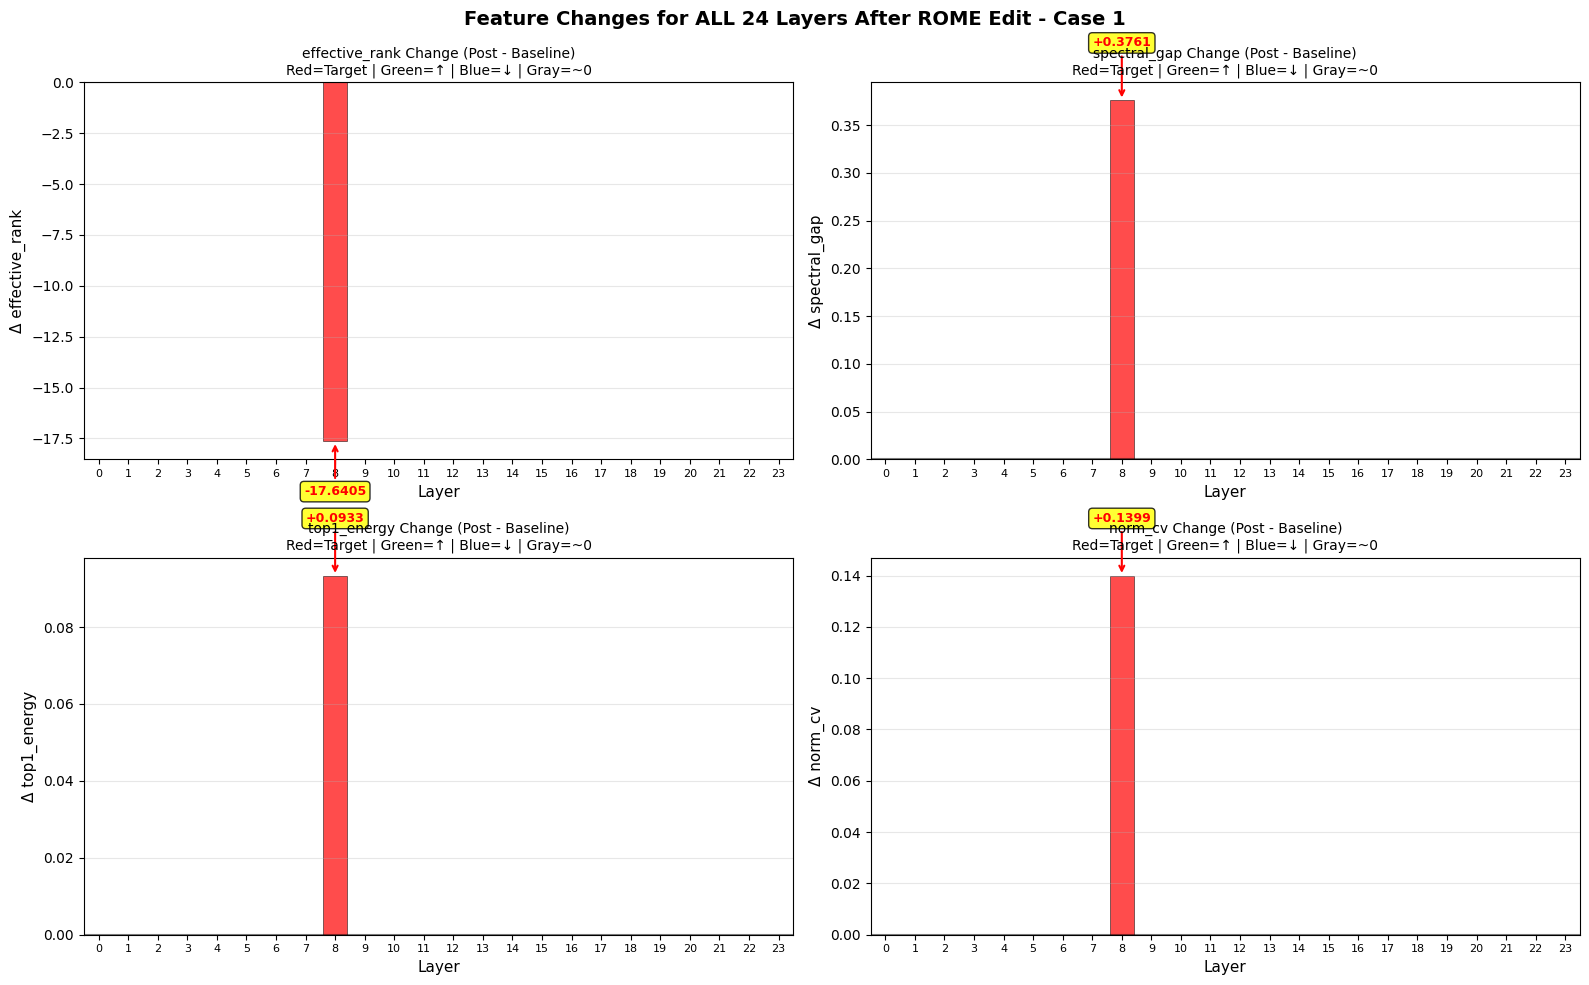


DETAILED CHANGE SUMMARY FOR ALL 24 LAYERS

EFFECTIVE_RANK:
  Target layer 8: -17.640503
  All other layers have zero/negligible change

SPECTRAL_GAP:
  Target layer 8: +0.376135
  All other layers have zero/negligible change

TOP1_ENERGY:
  Target layer 8: +0.093328
  All other layers have zero/negligible change

NORM_CV:
  Target layer 8: +0.139893
  All other layers have zero/negligible change


In [86]:
# Visualize differences: Target Layer vs ALL Other Layers
if 'df_diff' in dir():
    metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    
    # Get the actual layer indices from the dataframe
    all_layers = sorted(df_diff.index.tolist())
    print(f"DEBUG: Showing {len(all_layers)} layers: {all_layers}")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for ax, metric in zip(axes, metrics):
        # Get values for ALL layers
        vals = [df_diff.loc[l, metric] if l in df_diff.index else 0 for l in all_layers]
        
        # Debug: show value range
        non_zero_vals = [v for v in vals if abs(v) > 1e-10]
        print(f"{metric}: {len(non_zero_vals)} non-zero values out of {len(vals)} total")
        
        # Color coding: red=target, green=positive change, blue=negative change
        colors = []
        for l, v in zip(all_layers, vals):
            if l == target_layer:
                colors.append('red')
            elif abs(v) < 1e-10:  # essentially zero
                colors.append('lightgray')
            elif v > 0:
                colors.append('green')
            else:
                colors.append('blue')
        
        # Create bars with explicit positioning
        bars = ax.bar(range(len(all_layers)), vals, color=colors, alpha=0.7, 
                      edgecolor='black', linewidth=0.5, width=0.8)
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
        
        # Set x-axis to show ALL layer numbers
        ax.set_xlabel('Layer', fontsize=11)
        ax.set_ylabel(f'Δ {metric}', fontsize=11)
        ax.set_title(f'{metric} Change (Post - Baseline)\nRed=Target | Green=↑ | Blue=↓ | Gray=~0', fontsize=10)
        ax.set_xticks(range(len(all_layers)))
        ax.set_xticklabels(all_layers, fontsize=8)
        ax.set_xlim(-0.5, len(all_layers) - 0.5)  # Ensure all bars are visible
        ax.grid(axis='y', alpha=0.3)
        
        # Annotate target layer with arrow
        target_idx = all_layers.index(target_layer)
        target_val = vals[target_idx]
        if abs(target_val) > 1e-10:
            abs_max = max(abs(v) for v in vals)
            offset = abs_max * 0.15 if target_val >= 0 else -abs_max * 0.15
            ax.annotate(f'{target_val:+.4f}', xy=(target_idx, target_val), 
                       xytext=(target_idx, target_val + offset),
                       ha='center', fontweight='bold', color='red', fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8),
                       arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    
    plt.suptitle(f'Feature Changes for ALL {len(all_layers)} Layers After ROME Edit - Case {SELECTED_CASE_ID}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary of ALL layers
    print(f"\n{'='*70}")
    print(f"DETAILED CHANGE SUMMARY FOR ALL {len(all_layers)} LAYERS")
    print(f"{'='*70}")
    for metric in metrics:
        vals = [df_diff.loc[l, metric] if l in df_diff.index else 0 for l in all_layers]
        target_idx = all_layers.index(target_layer)
        target_change = vals[target_idx]
        other_changes = [v for i, v in enumerate(vals) if all_layers[i] != target_layer and abs(v) > 1e-10]
        
        print(f"\n{metric.upper()}:")
        print(f"  Target layer {target_layer}: {target_change:+.6f}")
        if other_changes:
            print(f"  Other non-zero layers: {len(other_changes)}/{len(all_layers)-1}")
            print(f"  Other layers mean: {np.mean(other_changes):+.6f}")
            print(f"  Other layers range: [{np.min(other_changes):+.6f}, {np.max(other_changes):+.6f}]")
            print(f"  Positive changes: {sum(1 for v in vals if v > 1e-10)}")
            print(f"  Negative changes: {sum(1 for v in vals if v < -1e-10)}")
            print(f"  Near-zero changes: {sum(1 for v in vals if abs(v) <= 1e-10)}")
        else:
            print(f"  All other layers have zero/negligible change")

## 4. Cross-Case Summary (All Cases)

In [87]:
# Summary across all test cases
print("=== CROSS-CASE SUMMARY ===\n")

summary_rows = []
for test in data['tests']:
    if test.get('error'):
        continue
    
    row = {
        'case_id': test['case_id'],
        'subject': test['subject'][:25],
        'rome_success': test.get('rome', {}).get('success', False),
        'normal_detected': test.get('normal_detection', {}).get('anomalous_layer'),
        'normal_z_score': test.get('normal_detection', {}).get('layer_z_score', 0),
        'normal_correct': test.get('normal_detection', {}).get('anomalous_layer') == target_layer,
        'blind_detected': test.get('blind_detection', {}).get('anomalous_layer'),
        'blind_correct': test.get('blind_detection', {}).get('anomalous_layer') == target_layer,
        'is_likely_rome': test.get('normal_detection', {}).get('is_likely_rome', False),
        'rank_one_score': test.get('normal_detection', {}).get('rank_one_score', 0),
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

# Accuracy stats
n_tests = len(df_summary)
print(f"\n--- Detection Accuracy ---")
print(f"Total valid tests: {n_tests}")
print(f"ROME success rate: {df_summary['rome_success'].sum()}/{n_tests} ({df_summary['rome_success'].mean()*100:.1f}%)")
print(f"Normal detection accuracy: {df_summary['normal_correct'].sum()}/{n_tests} ({df_summary['normal_correct'].mean()*100:.1f}%)")
print(f"Blind detection accuracy: {df_summary['blind_correct'].sum()}/{n_tests} ({df_summary['blind_correct'].mean()*100:.1f}%)")
print(f"ROME signature detected: {df_summary['is_likely_rome'].sum()}/{n_tests} ({df_summary['is_likely_rome'].mean()*100:.1f}%)")

=== CROSS-CASE SUMMARY ===



,case_id,subject,rome_success,normal_detected,normal_z_score,normal_correct,blind_detected,blind_correct,is_likely_rome,rank_one_score
0,0,Danielle Darrieux,True,8,4.795832,True,5,False,True,1.0
1,1,Edwin of Northumbria,True,8,4.795832,True,8,True,True,1.0
2,2,Toko Yasuda,True,8,4.795832,True,8,True,True,1.0
3,3,Autonomous University of,True,8,4.795832,True,8,True,True,1.0
4,4,Lyon,False,8,4.795832,True,5,False,True,1.0



--- Detection Accuracy ---
Total valid tests: 5
ROME success rate: 4/5 (80.0%)
Normal detection accuracy: 5/5 (100.0%)
Blind detection accuracy: 3/5 (60.0%)
ROME signature detected: 5/5 (100.0%)


## 5. Heatmap: All Metrics Across All Layers

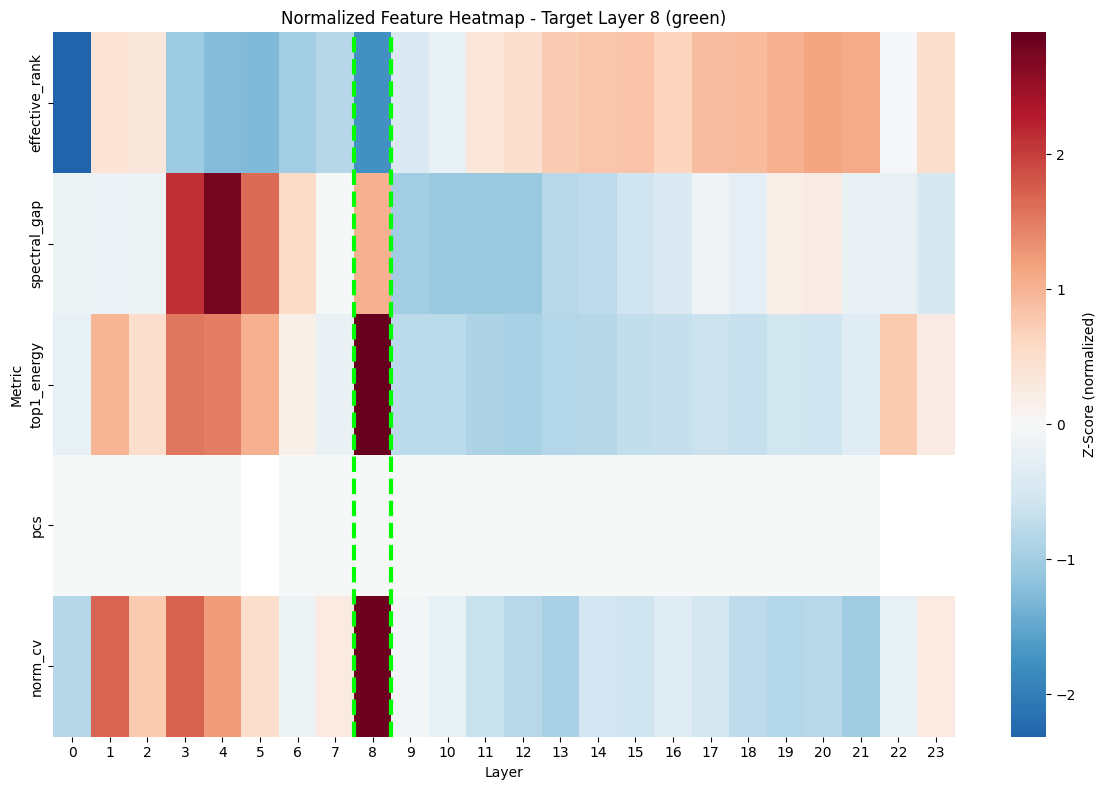


--- Target Layer 8 Z-Scores ---
  effective_rank: -1.762 
  spectral_gap: +1.011 
  top1_energy: +2.905 ⚠️ OUTLIER
  pcs: +0.000 
  norm_cv: +2.843 ⚠️ OUTLIER


In [88]:
# Comprehensive heatmap of blind detection features
if blind and 'layer_features' in blind:
    # Normalize features for comparison
    df_norm = (df_layers - df_layers.mean()) / (df_layers.std() + 1e-10)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create heatmap with target layer highlighted
    mask = np.zeros_like(df_norm.values)
    hm = sns.heatmap(df_norm.T, cmap='RdBu_r', center=0, annot=False, 
                      xticklabels=df_norm.index, yticklabels=df_norm.columns, ax=ax,
                      cbar_kws={'label': 'Z-Score (normalized)'})
    
    # Highlight target layer column
    ax.axvline(x=list(df_norm.index).index(target_layer), color='lime', linewidth=3, linestyle='--')
    ax.axvline(x=list(df_norm.index).index(target_layer)+1, color='lime', linewidth=3, linestyle='--')
    
    ax.set_xlabel('Layer')
    ax.set_ylabel('Metric')
    ax.set_title(f'Normalized Feature Heatmap - Target Layer {target_layer} (green)')
    plt.tight_layout()
    plt.show()
    
    # Z-score summary for target layer
    print(f"\n--- Target Layer {target_layer} Z-Scores ---")
    for col in df_norm.columns:
        z = df_norm.loc[target_layer, col]
        if not np.isnan(z):
            flag = "⚠️ OUTLIER" if abs(z) > 2 else ""
            print(f"  {col}: {z:+.3f} {flag}")

## 6. Outlier Neuron Analysis

In [89]:
# Outlier neuron comparison: baseline vs post-edit
if baseline_blind and case_blind:
    print("=== OUTLIER NEURON ANALYSIS ===\n")
    
    baseline_outliers = set(baseline_blind.get('outlier_neuron_indices', []))
    post_outliers = set(case_blind.get('outlier_neuron_indices', []))
    
    new_outliers = post_outliers - baseline_outliers
    removed_outliers = baseline_outliers - post_outliers
    persistent_outliers = baseline_outliers & post_outliers
    
    print(f"Baseline outlier count: {len(baseline_outliers)}")
    print(f"Post-edit outlier count: {len(post_outliers)}")
    print(f"Baseline outlier fraction: {baseline_blind.get('outlier_neuron_fraction', 0):.4f}")
    print(f"Post-edit outlier fraction: {case_blind.get('outlier_neuron_fraction', 0):.4f}")
    
    print(f"\n--- Outlier Changes ---")
    print(f"New outliers after edit: {len(new_outliers)}")
    print(f"Outliers removed after edit: {len(removed_outliers)}")
    print(f"Persistent outliers: {len(persistent_outliers)}")
    
    if new_outliers:
        print(f"\nNew outlier indices (first 20): {sorted(list(new_outliers))[:20]}")
    
    # Rank recovery comparison
    baseline_rr = baseline_blind.get('rank_recovery', 0)
    post_rr = case_blind.get('rank_recovery', 0)
    print(f"\n--- Rank Recovery ---")
    print(f"Baseline: {baseline_rr:.4f}")
    print(f"Post-edit: {post_rr:.4f}")
    print(f"Change: {post_rr - baseline_rr:+.4f}")

=== OUTLIER NEURON ANALYSIS ===

Baseline outlier count: 205
Post-edit outlier count: 205
Baseline outlier fraction: 0.0500
Post-edit outlier fraction: 0.0500

--- Outlier Changes ---
New outliers after edit: 191
Outliers removed after edit: 191
Persistent outliers: 14

New outlier indices (first 20): [2, 5, 37, 49, 67, 106, 110, 120, 124, 141, 172, 175, 211, 234, 248, 273, 276, 316, 333, 343]

--- Rank Recovery ---
Baseline: 9.4357
Post-edit: 16.8260
Change: +7.3903


## 7. Consistency Anomalies

In [90]:
# Consistency anomalies: which layers have unusual metrics
if case_blind and 'consistency_anomalies' in case_blind:
    print("=== CONSISTENCY ANOMALIES ===\n")
    print(f"Consistency score: {case_blind.get('consistency_score', 0):.4f}")
    print(f"Is likely modified: {case_blind.get('is_likely_modified', False)}")
    print(f"Confidence: {case_blind.get('confidence', 0):.4f}")
    
    anomalies = case_blind['consistency_anomalies']
    if anomalies:
        print(f"\n--- Detected Anomalies ---")
        df_anomalies = pd.DataFrame(anomalies)
        display(df_anomalies)
        
        # Check if target layer is among anomalies
        anomaly_layers = [a['layer'] for a in anomalies]
        if target_layer in anomaly_layers:
            print(f"\n✓ Target layer {target_layer} is in anomaly list")
        else:
            print(f"\n✗ Target layer {target_layer} is NOT in anomaly list")
            print(f"  Anomaly layers: {anomaly_layers}")
    else:
        print("\nNo consistency anomalies detected")
else:
    print("No consistency anomaly data available")

=== CONSISTENCY ANOMALIES ===

Consistency score: 0.9792
Is likely modified: False
Confidence: 0.0000

--- Detected Anomalies ---


,layer,metric,z_score,diff
0,1,effective_rank,3.537654,22.888550
1,9,spectral_norm,3.171857,42.090469



✗ Target layer 8 is NOT in anomaly list
  Anomaly layers: [1, 9]


## 8. Radar Chart: Target Layer Profile

Using 5 metrics: ['effective_rank', 'spectral_gap', 'top1_energy', 'pcs', 'norm_cv']


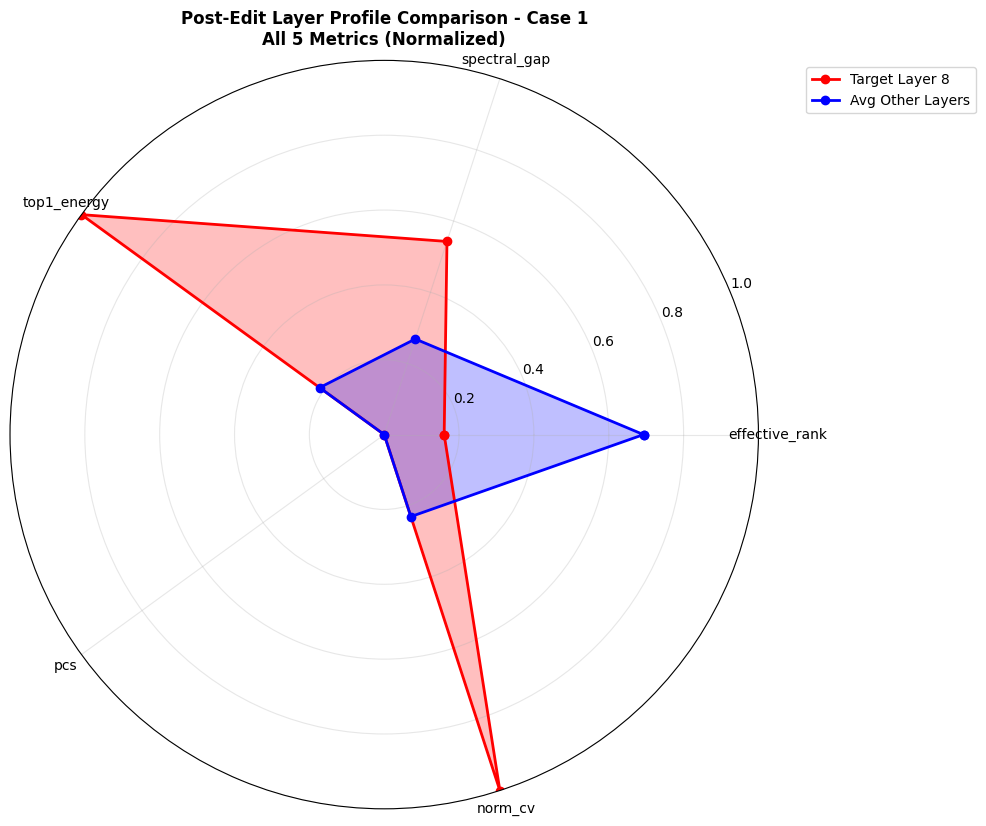

In [ ]:
# Radar chart comparing target layer to average of other layers - ALL METRICS
if blind and 'layer_features' in blind:
    from math import pi
    
    # Get ALL available metrics from the dataframe
    metrics = [col for col in df_layers.columns if col in ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv', 'pcs']]
    print(f"Using {len(metrics)} metrics: {metrics}")
    
    # Get normalized values
    target_vals = []
    avg_other_vals = []
    
    for m in metrics:
        col = df_layers[m].replace([np.inf, -np.inf], np.nan).dropna()
        if len(col) == 0:
            target_vals.append(0)
            avg_other_vals.append(0)
            continue
            
        # Normalize to 0-1 range
        min_val, max_val = col.min(), col.max()
        if max_val - min_val < 1e-10:
            normalized = col * 0  # All same value, normalize to 0
        else:
            normalized = (col - min_val) / (max_val - min_val)
        
        target_vals.append(normalized.loc[target_layer] if target_layer in normalized.index else 0)
        other_vals = normalized.loc[normalized.index != target_layer]
        avg_other_vals.append(other_vals.mean() if len(other_vals) > 0 else 0)
    
    # Close the radar chart
    target_vals += target_vals[:1]
    avg_other_vals += avg_other_vals[:1]
    metrics_plot = metrics + metrics[:1]
    
    # Create radar chart
    angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    ax.plot(angles, target_vals, 'o-', linewidth=2, label=f'Target Layer {target_layer}', color='red')
    ax.fill(angles, target_vals, alpha=0.25, color='red')
    
    ax.plot(angles, avg_other_vals, 'o-', linewidth=2, label='Avg Other Layers', color='blue')
    ax.fill(angles, avg_other_vals, alpha=0.25, color='blue')
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.set_title(f'Post-Edit Layer Profile Comparison - Case {SELECTED_CASE_ID}\nAll {len(metrics)} Metrics (Normalized)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


=== ALL LAYERS BASELINE vs POST-EDIT COMPARISON ===
Showing 24 layers with 5 metrics each


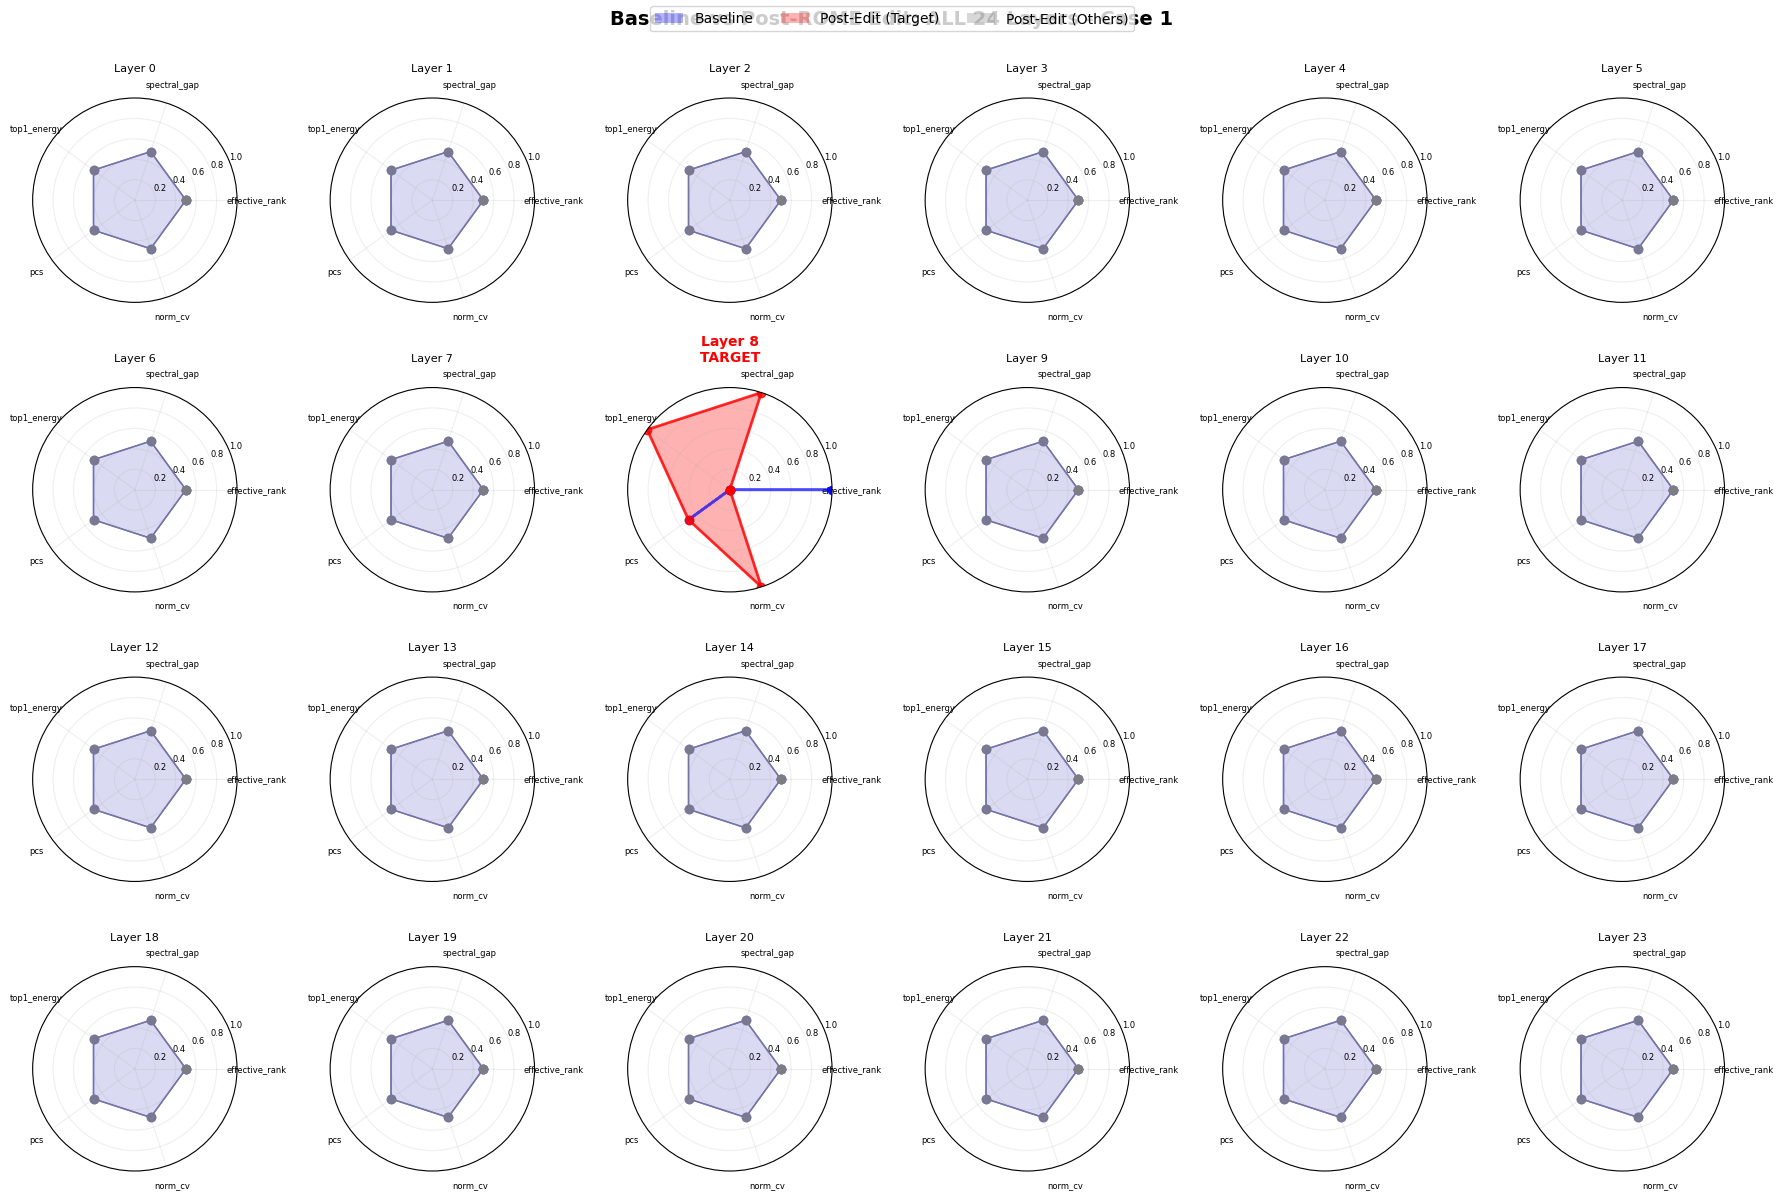

In [92]:
# Radar charts: ALL Layers Baseline vs Post-Edit (Grid View)
if baseline_blind and case_blind and 'layer_features' in baseline_blind and 'layer_features' in case_blind:
    from math import pi
    
    # Get ALL available metrics
    metrics = [col for col in df_baseline.columns if col in ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv', 'pcs']]
    
    # Get all layers
    all_layers = sorted(df_baseline.index.tolist())
    print(f"\n=== ALL LAYERS BASELINE vs POST-EDIT COMPARISON ===")
    print(f"Showing {len(all_layers)} layers with {len(metrics)} metrics each")
    
    # Create grid of radar charts (4x6 for 24 layers)
    n_cols = 6
    n_rows = (len(all_layers) + n_cols - 1) // n_cols
    
    fig = plt.figure(figsize=(18, 3*n_rows))
    
    for idx, layer in enumerate(all_layers):
        ax = plt.subplot(n_rows, n_cols, idx+1, projection='polar')
        
        # Get values for this layer
        baseline_vals_raw = []
        post_vals_raw = []
        
        for m in metrics:
            baseline_val = df_baseline.loc[layer, m] if layer in df_baseline.index else np.nan
            post_val = df_post.loc[layer, m] if layer in df_post.index else np.nan
            
            # Handle inf/nan
            if np.isinf(baseline_val) or np.isnan(baseline_val):
                baseline_val = 0
            if np.isinf(post_val) or np.isnan(post_val):
                post_val = 0
                
            baseline_vals_raw.append(baseline_val)
            post_vals_raw.append(post_val)
        
        # Normalize each metric
        baseline_vals_norm = []
        post_vals_norm = []
        
        for i in range(len(metrics)):
            min_val = min(baseline_vals_raw[i], post_vals_raw[i])
            max_val = max(baseline_vals_raw[i], post_vals_raw[i])
            
            if max_val - min_val < 1e-10:
                baseline_vals_norm.append(0.5)
                post_vals_norm.append(0.5)
            else:
                baseline_vals_norm.append((baseline_vals_raw[i] - min_val) / (max_val - min_val))
                post_vals_norm.append((post_vals_raw[i] - min_val) / (max_val - min_val))
        
        # Close the radar chart
        baseline_vals_norm += baseline_vals_norm[:1]
        post_vals_norm += post_vals_norm[:1]
        
        # Create angles
        angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
        angles += angles[:1]
        
        # Plot
        color = 'red' if layer == target_layer else 'gray'
        linewidth = 2 if layer == target_layer else 1
        alpha_fill = 0.3 if layer == target_layer else 0.1
        
        ax.plot(angles, baseline_vals_norm, 'o-', linewidth=linewidth, color='blue', alpha=0.6)
        ax.fill(angles, baseline_vals_norm, alpha=alpha_fill, color='blue')
        
        ax.plot(angles, post_vals_norm, 'o-', linewidth=linewidth, color=color, alpha=0.8)
        ax.fill(angles, post_vals_norm, alpha=alpha_fill, color=color)
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics, fontsize=6)
        ax.set_ylim(0, 1)
        
        # Title with emphasis on target layer
        if layer == target_layer:
            ax.set_title(f'Layer {layer}\n TARGET ', fontsize=10, fontweight='bold', color='red')
        else:
            ax.set_title(f'Layer {layer}', fontsize=8)
        
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=6)
    
    # Add legend to the figure
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', alpha=0.3, label='Baseline'),
        Patch(facecolor='red', alpha=0.3, label='Post-Edit (Target)'),
        Patch(facecolor='gray', alpha=0.3, label='Post-Edit (Others)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=10)
    
    plt.suptitle(f'Baseline vs Post-ROME Edit: ALL {len(all_layers)} Layers - Case {SELECTED_CASE_ID}', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()
else:
    print("Baseline or post-edit data not available for all layers comparison")